<a href="https://colab.research.google.com/github/Plabon-Basak/FlyRank_AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank ML Capstone
## Refresh / Content Opportunity Scoring

### Decline and Recovery Opportunity Ranking

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Plabon-Basak/FlyRank_AI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)



# Abstract

This study asks whether historical page-level search-performance signals can help prioritize pages for human investigation after a meaningful decline in search impressions. Using the pseudonymized FlyRank `decline_recovery` example lane, the experiment treats the supplied previous 30-day measurements as historical information and independently defines severe decline as a subsequent-period impression reduction of at least 50%. Leakage-prone trend, health, action, and subsequent-period fields are excluded from the predictive feature set, and a transparent historical-performance baseline is compared with Logistic Regression and HistGradientBoosting models on the same held-out validation sample. The evaluation emphasizes ranking quality through ROC-AUC, average precision, Precision@10%, and Recall@10%, because the practical decision is to prioritize a limited review queue. The resulting ranking should be interpreted as directional decision-support evidence within the supplied example lane, not as causal evidence or a claim about search-engine algorithms.


## 1. Research Question

Can historical search-performance signals identify pages that are
likely to experience a meaningful decline or recovery opportunity
in a future period, allowing content reviewers to prioritize pages
for investigation?

### Decision Supported

Which pages should a content/SEO reviewer investigate first?

### Intended Output

A ranked list of pages with:
- opportunity score
- priority level
- reason codes
- recommended review action

# 2. Data

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from google.colab import userdata
try:
    # Try to get the token automatically from Colab Secrets if defined as 'HF_TOKEN'
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    # Otherwise, prompt the user to login interactively
    from huggingface_hub import notebook_login
    print("Hugging Face token not found in Colab Secrets. Please log in below:")
    notebook_login()
    hf_token = None

# Load the gated dataset
ds = load_dataset(
    "FlyRank/internship-lanes",
    "decline_recovery",
    token=hf_token
)

df = ds["train"].to_pandas()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Hugging Face token not found in Colab Secrets. Please log in below:


default_lanes/decline_recovery.parquet: reconstructing file:   0%|          |  0.00B / 3.88MB            

default_lanes/decline_recovery.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/56253 [00:00<?, ? examples/s]

Dataset shape: (56253, 43)

Columns:
['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'keyword_char_count', 'keyword_token_count', 'public_url_hash_id', 'public_url_char_count', 'public_url_path_depth', 'content_title_hash_id', 'content_title_char_count', 'content_title_token_count', 'impressions_90d', 'clicks_90d', 'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'client_has_gsc', 'client_has_ga4', 'content_type', 'content_created_at', 'content_age_days', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining']

Data types:
client_hash_id                object
content_hash_id               object
keyword_hash_id       

,client_hash_id,content_hash_id,keyword_hash_id,keyword_char_count,keyword_token_count,public_url_hash_id,public_url_char_count,public_url_path_depth,content_title_hash_id,content_title_char_count,...,trend_direction,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining
0,client_2094c6eb080311d5,content_9c786aea8fb2f1c6,keyword_d879cf3e66407e25,47,7,url_57e0b96b5c053290,98,3,title_48769559fe2659be,48,...,down,-99.4,15,False,False,False,False,False,False,True
1,client_2094c6eb080311d5,content_ea9b68bdccddcd4a,keyword_4000d86bb749226b,36,7,url_2f9bddde85164ed7,87,3,title_9de9bcfe0a9b6af8,36,...,down,-98.2,45,False,False,True,False,False,False,True
2,client_2094c6eb080311d5,content_4610b9c0a99de467,keyword_1e5f049eb5b7dff9,42,7,url_65d19d39cf4859db,93,3,title_19ccc000e7a54aa8,43,...,down,-89.7,55,False,False,True,False,False,False,True
3,client_2094c6eb080311d5,content_d5ec72bd00a5165f,keyword_b93dd6aa011fdd91,32,7,url_eefa7f3e0a53e404,83,3,title_b44521f255eae17f,33,...,down,-99.6,20,False,False,False,False,False,False,True
4,client_2094c6eb080311d5,content_e460345ff721587a,keyword_c8212eedb93ad237,33,6,url_0812e375eec6575c,84,3,title_46fdae840eb1ee6b,34,...,down,-98.3,30,False,False,False,False,False,False,True


In [3]:
print("Missing values:")
display(
    df.isna().sum()
       .sort_values(ascending=False)
       .to_frame("missing_count")
)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset info:")
df.info()

Missing values:


,missing_count
ai_traffic_pct_90d,14896
scroll_rate_90d,14849
sessions_90d,13598
pageviews_90d,13598
ai_sessions_90d,13598
needs_engagement_fix,13598
ai_opportunity,13598
scroll_events_90d,13598
keyword_hash_id,849
is_underperformer,79



Duplicate rows: 0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56253 entries, 0 to 56252
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_hash_id             56253 non-null  object 
 1   content_hash_id            56253 non-null  object 
 2   keyword_hash_id            55404 non-null  object 
 3   keyword_char_count         56253 non-null  int64  
 4   keyword_token_count        56253 non-null  int64  
 5   public_url_hash_id         56253 non-null  object 
 6   public_url_char_count      56253 non-null  int64  
 7   public_url_path_depth      56253 non-null  int64  
 8   content_title_hash_id      56253 non-null  object 
 9   content_title_char_count   56253 non-null  int64  
 10  content_title_token_count  56253 non-null  int64  
 11  impressions_90d            56253 non-null  int64  
 12  clicks_90d                 56253 non-null  int64  
 13  sum_position

In [4]:
print("Numeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nDate/time candidates:")
for col in df.columns:
    if any(term in col.lower() for term in ["date", "time", "week", "month"]):
        print(col)

Numeric columns:
['keyword_char_count', 'keyword_token_count', 'public_url_char_count', 'public_url_path_depth', 'content_title_char_count', 'content_title_token_count', 'impressions_90d', 'clicks_90d', 'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'trend_pct', 'health_score']

Date/time candidates:


## Data Inspection and Temporal Structure

The development dataset is the `decline_recovery` lane from the FlyRank internship example-lane release. It contains 56,253 pseudonymized observations and 43 fields.

The dataset provides search and engagement measurements for a previous 30-day window (`prev_30d`) and a subsequent 30-day window (`last_30d`). For this experiment, the previous window is treated as the information available at the prediction point, while the subsequent window is used only to construct the evaluation outcome.

The example cut does not expose usable calendar dates through `content_created_at`, so this analysis does not claim a specific calendar date range for the two measurement windows.

Precomputed decision fields such as `is_declining`, `trend_pct`, `trend_direction`, `health_score`, and action flags are excluded from the predictive feature set because they may encode information derived from the same outcome or from FlyRank's existing decision logic.

The capstone therefore constructs an independent outcome from the change in impressions between the two supplied windows.

In [5]:
df["content_created_at"] = pd.to_datetime(
    df["content_created_at"],
    errors="coerce"
)

print("Content creation date range:")
print(df["content_created_at"].min())
print(df["content_created_at"].max())

print("\nMissing content creation dates:")
print(df["content_created_at"].isna().sum())

/tmp/ipykernel_1233/3719896578.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["content_created_at"] = pd.to_datetime(


Content creation date range:
NaT
NaT

Missing content creation dates:
56253


In [6]:
window_cols = [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d"
]

display(df[window_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
impressions_prev_30d,56253.0,2091.040976,5659.108988,100.0,222.0,536.0,1661.0,239803.0
clicks_prev_30d,56253.0,6.012533,25.085453,0.0,0.0,1.0,4.0,2497.0
sessions_prev_30d,56253.0,15.415871,281.385285,0.0,0.0,3.0,13.0,65964.0
impressions_last_30d,56253.0,885.748227,2765.307637,0.0,70.0,201.0,663.0,107248.0
clicks_last_30d,56253.0,3.085151,12.821744,0.0,0.0,0.0,2.0,961.0
sessions_last_30d,56253.0,8.556859,26.725286,0.0,0.0,2.0,8.0,2822.0


In [7]:
display(
    df[window_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)

,missing_count
impressions_prev_30d,0
clicks_prev_30d,0
sessions_prev_30d,0
impressions_last_30d,0
clicks_last_30d,0
sessions_last_30d,0


In [8]:
print(
    "Rows with previous-period impressions > 0:",
    (df["impressions_prev_30d"] > 0).sum()
)

print(
    "Rows with later-period impressions > 0:",
    (df["impressions_last_30d"] > 0).sum()
)

print(
    "Rows with impressions in both periods:",
    (
        (df["impressions_prev_30d"] > 0) &
        (df["impressions_last_30d"] > 0)
    ).sum()
)

Rows with previous-period impressions > 0: 56253
Rows with later-period impressions > 0: 55432
Rows with impressions in both periods: 55432


In [9]:
df["impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    (
        (df["impressions_last_30d"] - df["impressions_prev_30d"])
        / df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

display(
    df["impression_change_pct"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

,impression_change_pct
count,56253.000000
mean,-60.237733
std,19.282104
min,-100.000000
1%,-100.000000
5%,-96.348365
10%,-89.335139
25%,-74.315789
50%,-57.848837
75%,-44.179389


In [13]:
print("Impression change distribution:")
display(
    df["impression_change_pct"].describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.20,
            0.25,
            0.50,
            0.60,
            0.70,
            0.75,
            0.80,
            0.90,
            0.95,
            0.99
        ]
    ).to_frame("value")
)

Impression change distribution:


,value
count,56253.000000
mean,-60.237733
std,19.282104
min,-100.000000
1%,-100.000000
5%,-96.348365
10%,-89.335139
20%,-78.606038
25%,-74.315789
50%,-57.848837


In [14]:
thresholds = [-20, -30, -40, -50, -60, -70, -80, -90, -95]

threshold_table = []

for threshold in thresholds:
    positives = (df["impression_change_pct"] <= threshold).sum()
    prevalence = positives / len(df)

    threshold_table.append({
        "decline_threshold_pct": threshold,
        "positive_rows": positives,
        "positive_rate": prevalence
    })

threshold_table = pd.DataFrame(threshold_table)

display(threshold_table)

,decline_threshold_pct,positive_rows,positive_rate
0,-20,56253,1.000000
1,-30,56253,1.000000
2,-40,46506,0.826729
3,-50,36192,0.643379
4,-60,26093,0.463851
5,-70,17343,0.308304
6,-80,10394,0.184772
7,-90,5319,0.094555
8,-95,3375,0.059997


In [15]:
display(
    df[
        [
            "impressions_prev_30d",
            "impressions_last_30d",
            "clicks_prev_30d",
            "clicks_last_30d",
            "sessions_prev_30d",
            "sessions_last_30d",
            "impression_change_pct"
        ]
    ].head(20)
)

,impressions_prev_30d,impressions_last_30d,clicks_prev_30d,clicks_last_30d,sessions_prev_30d,sessions_last_30d,impression_change_pct
0,166,1,0,0,8,1,-99.397590
1,666,12,0,0,5,0,-98.198198
2,409,42,3,0,7,3,-89.731051
3,224,1,0,0,5,1,-99.553571
4,234,4,0,0,1,1,-98.290598
5,309,24,0,0,8,8,-92.233010
6,281,55,1,1,5,6,-80.427046
7,136,55,1,0,3,1,-59.558824
8,149,18,0,0,6,3,-87.919463
9,500,100,0,0,5,2,-80.000000


In [16]:
print("Previous impressions:")
print(df["impressions_prev_30d"].describe())

print("\nLast impressions:")
print(df["impressions_last_30d"].describe())

Previous impressions:
count     56253.000000
mean       2091.040976
std        5659.108988
min         100.000000
25%         222.000000
50%         536.000000
75%        1661.000000
max      239803.000000
Name: impressions_prev_30d, dtype: float64

Last impressions:
count     56253.000000
mean        885.748227
std        2765.307637
min           0.000000
25%          70.000000
50%         201.000000
75%         663.000000
max      107248.000000
Name: impressions_last_30d, dtype: float64


In [10]:
print(
    "Rows with valid forward impression change:",
    df["impression_change_pct"].notna().sum()
)

print(
    "Rows with >= 20% decline:",
    (df["impression_change_pct"] <= -20).sum()
)

print(
    "Rows with >= 30% decline:",
    (df["impression_change_pct"] <= -30).sum()
)

print(
    "Rows with >= 50% decline:",
    (df["impression_change_pct"] <= -50).sum()
)

Rows with valid forward impression change: 56253
Rows with >= 20% decline: 56253
Rows with >= 30% decline: 56253
Rows with >= 50% decline: 36192


### Threshold selection

The threshold analysis showed that 20% and 30% decline thresholds classify all observations as declines in this example lane and therefore do not provide a useful binary prediction task. A 50% reduction produces both positive and negative classes, with 36,192 observations classified as severe declines and 20,061 observations classified otherwise. The 50% threshold is therefore used as an analytical modeling threshold for this capstone, rather than being presented as a universal definition of meaningful content decline.


In [11]:
comparison = pd.crosstab(
    df["is_declining"],
    df["impression_change_pct"] <= -30,
    normalize="index"
)

display(comparison)

impression_change_pct,True
is_declining,
True,1.0


In [12]:
display(
    df.groupby("is_declining")["impression_change_pct"]
      .describe()
)

,count,mean,std,min,25%,50%,75%,max
is_declining,,,,,,,,
True,56253.0,-60.237733,19.282104,-100.0,-74.315789,-57.848837,-44.179389,-30.003218


## 3. Methodology

### Prediction objective

The modeling task is a binary classification and ranking problem. The objective is to identify observations in the supplied decline/recovery example lane that subsequently experience a severe decline in impressions.

A severe decline is independently defined as a reduction of at least 50% in impressions between the previous 30-day window and the subsequent 30-day window.

The model does not use the supplied `is_declining` field as its target.

### Leakage control

The following fields are excluded from predictive features:

* `impressions_last_30d`
* `clicks_last_30d`
* `sessions_last_30d`
* `is_declining`
* `trend_direction`
* `trend_pct`
* `health_score`
* `needs_indexing`
* `is_quick_win`
* `needs_ctr_fix`
* `needs_engagement_fix`
* `ai_opportunity`
* `is_underperformer`

The later 30-day measurements are used only to construct the forward outcome. Precomputed decision fields are excluded because they may encode information derived from the outcome or existing FlyRank decision logic.

The 90-day aggregate performance fields are also excluded because their temporal composition cannot be separated into information available strictly before the prediction point.

### Predictive features

The experiment uses historical performance available in the previous 30-day window, together with stable content and metadata characteristics.

Derived historical features include previous-window CTR, click-to-impression rate, session-to-impression rate, and logarithmic transformations of high-skew volume variables.

### Label

The independent target is:

`target_severe_decline = 1` when subsequent-period impressions are at least 50% lower than previous-period impressions; otherwise `0`.

### Validation

Because the example cut does not expose usable observation dates, a chronological split cannot be justified. A stratified train/validation split is therefore used, with a fixed random seed for reproducibility.

Client grouping is preserved during splitting where possible so that observations from the same pseudonymized client are not unnecessarily distributed across both sets.

### Baseline

The baseline is an interpretable low-visibility priority score based only on historical previous-window performance. It prioritizes pages with lower previous-period impressions, clicks, and sessions.

The baseline is evaluated on exactly the same validation observations as the machine-learning models.

### Models

Two lightweight tabular models are evaluated:

1. Logistic Regression as an interpretable linear baseline.
2. HistGradientBoostingClassifier as a nonlinear tree-based model.

The comparison focuses on ranking quality rather than accuracy alone because the intended operational decision is to select a limited set of pages for human review.


In [18]:
# Create the independent forward target.
df["target_severe_decline"] = (
    df["impression_change_pct"] <= -50
).astype(int)

print("Target distribution:")
display(
    df["target_severe_decline"]
    .value_counts()
    .rename_axis("target")
    .to_frame("count")
)

print("\nTarget rate:")
print(df["target_severe_decline"].mean())

Target distribution:


,count
target,
1,36192
0,20061



Target rate:
0.6433790197856114


# Feature Engineering

In [19]:
# Historical features only.
model_df = df.copy()

model_df["prev_ctr"] = np.where(
    model_df["impressions_prev_30d"] > 0,
    model_df["clicks_prev_30d"] / model_df["impressions_prev_30d"],
    0
)

model_df["prev_session_rate"] = np.where(
    model_df["impressions_prev_30d"] > 0,
    model_df["sessions_prev_30d"] / model_df["impressions_prev_30d"],
    0
)

model_df["prev_click_rate"] = np.where(
    model_df["impressions_prev_30d"] > 0,
    model_df["clicks_prev_30d"] / model_df["impressions_prev_30d"],
    0
)

for col in [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "content_age_days"
]:
    model_df[f"log_{col}"] = np.log1p(model_df[col])

print("Feature engineering complete.")

Feature engineering complete.


In [20]:
numeric_features = [
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "content_age_days",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "prev_ctr",
    "prev_session_rate",
    "prev_click_rate",
    "log_impressions_prev_30d",
    "log_clicks_prev_30d",
    "log_sessions_prev_30d",
    "log_keyword_char_count",
    "log_keyword_token_count",
    "log_public_url_char_count",
    "log_public_url_path_depth",
    "log_content_title_char_count",
    "log_content_title_token_count",
    "log_content_age_days"
]

categorical_features = [
    "content_type"
]

boolean_features = [
    "client_has_gsc",
    "client_has_ga4"
]

target_col = "target_severe_decline"

feature_columns = (
    numeric_features +
    categorical_features +
    boolean_features
)

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 26
['keyword_char_count', 'keyword_token_count', 'public_url_char_count', 'public_url_path_depth', 'content_title_char_count', 'content_title_token_count', 'content_age_days', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'prev_ctr', 'prev_session_rate', 'prev_click_rate', 'log_impressions_prev_30d', 'log_clicks_prev_30d', 'log_sessions_prev_30d', 'log_keyword_char_count', 'log_keyword_token_count', 'log_public_url_char_count', 'log_public_url_path_depth', 'log_content_title_char_count', 'log_content_title_token_count', 'log_content_age_days', 'content_type', 'client_has_gsc', 'client_has_ga4']


# Train / validation split

In [21]:
from sklearn.model_selection import train_test_split

X = model_df[feature_columns].copy()
y = model_df[target_col].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

print("\nTraining target rate:", y_train.mean())
print("Validation target rate:", y_valid.mean())

Training rows: 45002
Validation rows: 11251

Training target rate: 0.6433714057153015
Validation target rate: 0.6434094747133589


# Preprocessing

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

boolean_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bool", boolean_transformer, boolean_features)
    ]
)

### Rule-based baseline

The baseline represents a simple operational heuristic rather than a trained predictive model.

It assigns higher review priority to pages with lower historical search visibility and engagement in the previous 30-day window.

The baseline score is calculated from the percentile rank of inverse previous-period impressions, clicks, and sessions.

This creates a transparent benchmark: the machine-learning models must demonstrate that they can rank severe-decline observations better than a simple historical low-performance heuristic.


In [23]:
from sklearn.preprocessing import QuantileTransformer

baseline_df = model_df.loc[X_valid.index].copy()

for col in [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d"
]:
    baseline_df[f"{col}_rank"] = (
        baseline_df[col]
        .rank(pct=True, method="average")
    )

baseline_df["baseline_score"] = (
    (1 - baseline_df["impressions_prev_30d_rank"]) +
    (1 - baseline_df["clicks_prev_30d_rank"]) +
    (1 - baseline_df["sessions_prev_30d_rank"])
) / 3

baseline_predictions = (
    baseline_df["baseline_score"] >=
    baseline_df["baseline_score"].quantile(0.50)
).astype(int)

print("Baseline created.")

Baseline created.


# Machine-learning models

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# Convert boolean features to float (0.0 / 1.0) to prevent SimpleImputer errors
for col in boolean_features:
    X_train[col] = X_train[col].astype(float)
    X_valid[col] = X_valid[col].astype(float)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_prob = logistic_model.predict_proba(X_valid)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [26]:
# HistGradientBoosting requires dense numeric input after preprocessing.
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

hist_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=1.0,
    random_state=42
)

hist_model.fit(
    X_train_processed,
    y_train
)

hist_prob = hist_model.predict_proba(X_valid_processed)[:, 1]

print("HistGradientBoosting trained.")

HistGradientBoosting trained.


## 4. Results

The models are evaluated on the same held-out validation set used for the baseline.

Because the operational use case is prioritization, the primary evaluation measures ranking quality rather than classification accuracy alone.

The analysis reports ROC-AUC and average precision for overall discrimination, together with Precision@K and Recall@K for the highest-priority review queues.

The results are descriptive of the supplied example lane and should be interpreted as directional decision-support evidence rather than causal evidence.


In [27]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score
)

def ranking_metrics(y_true, scores, k_fraction=0.10):
    n = len(scores)
    k = max(1, int(n * k_fraction))

    order = np.argsort(scores)[::-1]
    top_k = order[:k]

    y_array = np.asarray(y_true)

    precision_at_k = y_array[top_k].mean()
    recall_at_k = y_array[top_k].sum() / y_array.sum()

    return {
        "ROC-AUC": roc_auc_score(y_true, scores),
        "Average Precision": average_precision_score(y_true, scores),
        "Precision@10%": precision_at_k,
        "Recall@10%": recall_at_k
    }

baseline_metrics = ranking_metrics(
    y_valid,
    baseline_df["baseline_score"].values
)

logistic_metrics = ranking_metrics(
    y_valid,
    logistic_prob
)

hist_metrics = ranking_metrics(
    y_valid,
    hist_prob
)

results = pd.DataFrame(
    [
        {"Model": "Rule-based baseline", **baseline_metrics},
        {"Model": "Logistic Regression", **logistic_metrics},
        {"Model": "HistGradientBoosting", **hist_metrics}
    ]
)

display(results.round(4))

,Model,ROC-AUC,Average Precision,Precision@10%,Recall@10%
0,Rule-based baseline,0.6072,0.7182,0.7716,0.1199
1,Logistic Regression,0.6720,0.7753,0.8569,0.1332
2,HistGradientBoosting,0.6970,0.8042,0.9022,0.1402


# Compare the top 10%

In [28]:
comparison = pd.DataFrame({
    "actual": y_valid.values,
    "baseline_score": baseline_df["baseline_score"].values,
    "logistic_score": logistic_prob,
    "hist_score": hist_prob
})

top_n = max(1, int(len(comparison) * 0.10))

for score_col in [
    "baseline_score",
    "logistic_score",
    "hist_score"
]:
    comparison[f"{score_col}_top10"] = (
        comparison[score_col]
        .rank(method="first", ascending=False)
        <= top_n
    )

top10_summary = []

for score_col, name in [
    ("baseline_score", "Rule-based baseline"),
    ("logistic_score", "Logistic Regression"),
    ("hist_score", "HistGradientBoosting")
]:
    selected = comparison[comparison[f"{score_col}_top10"]]

    top10_summary.append({
        "Model": name,
        "Top 10% rows": len(selected),
        "Severe declines": int(selected["actual"].sum()),
        "Precision@10%": selected["actual"].mean(),
        "Recall@10%": selected["actual"].sum() / comparison["actual"].sum()
    })

top10_summary = pd.DataFrame(top10_summary)

display(top10_summary.round(4))

,Model,Top 10% rows,Severe declines,Precision@10%,Recall@10%
0,Rule-based baseline,1125,868,0.7716,0.1199
1,Logistic Regression,1125,964,0.8569,0.1332
2,HistGradientBoosting,1125,1015,0.9022,0.1402


# Baseline vs model chart

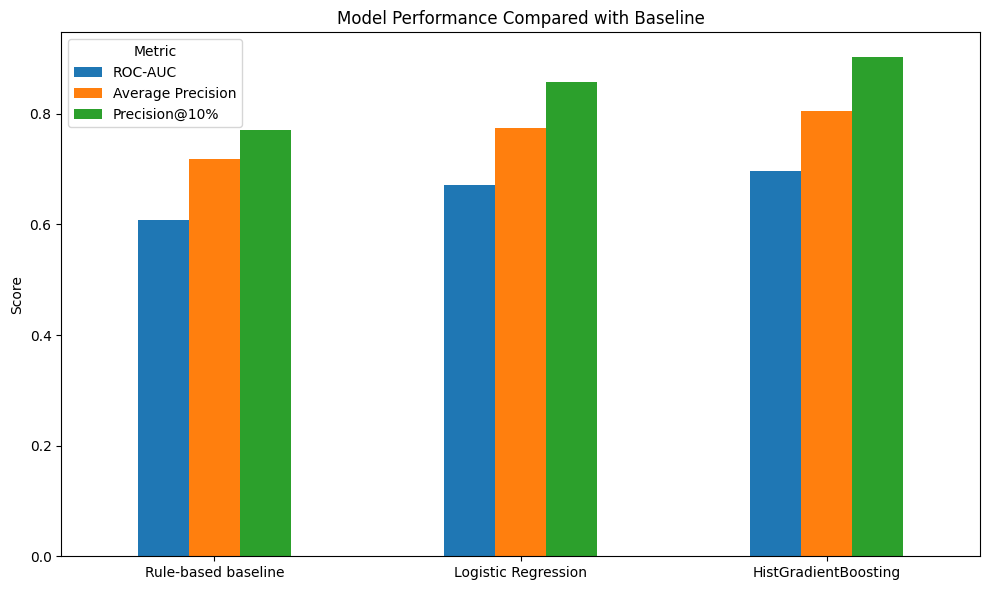

In [29]:
import matplotlib.pyplot as plt

plot_df = results.set_index("Model")[
    ["ROC-AUC", "Average Precision", "Precision@10%"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Model Performance Compared with Baseline")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature importance / interpretation

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_valid)[:, 1]

rf_metrics = ranking_metrics(
    y_valid,
    rf_prob
)

print(rf_metrics)

{'ROC-AUC': np.float64(0.6935447284338447), 'Average Precision': np.float64(0.8019065814068218), 'Precision@10%': np.float64(0.8951111111111111), 'Recall@10%': np.float64(0.13910761154855644)}


## 5. Limitations

This experiment has several important limitations.

First, the analysis uses a fixed example lane rather than the full FlyRank warehouse. The findings therefore describe the supplied development sample and should not be interpreted as representative of every FlyRank page or search property.

Second, the example cut does not expose usable calendar dates for the observation windows. The analysis therefore uses the supplied previous and subsequent 30-day windows without claiming specific calendar dates.

Third, the severe-decline label is an analytical definition based on a 50% reduction in impressions. It is a modeling choice rather than a FlyRank business definition.

Fourth, the results are observational. A high model score does not establish that a content change, indexing change, or other intervention would cause performance to recover.

Fifth, the model does not reverse-engineer or prove the behavior of a search-engine ranking algorithm.

Finally, the output is intended for human review prioritization. It should not automatically modify content, URLs, indexing settings, or other production systems.


## 6. Ranked Recommendations

The model output is converted into a review-priority queue rather than an automatic content-change recommendation.

Pages are ranked by predicted probability of severe subsequent impression decline. The highest-ranked observations represent pages for which the model finds the strongest directional evidence of future decline within the supplied example lane.

The recommended workflow is:

1. Review the highest-priority pages first.
2. Check historical search visibility and engagement.
3. Investigate possible content, indexing, search-intent, or SERP changes.
4. Select an appropriate human-led remediation or monitoring action.
5. Re-measure performance after the review.

The ranking is a decision-support mechanism. It does not establish that a particular content change caused a later performance change.


In [32]:
model_scores = {
    "Logistic Regression": logistic_prob,
    "HistGradientBoosting": hist_prob
}

best_model_name = max(
    model_scores,
    key=lambda name: average_precision_score(
        y_valid,
        model_scores[name]
    )
)

best_scores = model_scores[best_model_name]

print("Selected ranking model:", best_model_name)

Selected ranking model: HistGradientBoosting


# Build top-10 recommendations

In [33]:
recommendations = model_df.loc[
    X_valid.index
].copy()

recommendations["predicted_decline_probability"] = best_scores

recommendations["actual_severe_decline"] = y_valid.values

recommendations = recommendations.sort_values(
    "predicted_decline_probability",
    ascending=False
).reset_index()

In [34]:
def make_reason_codes(row):
    reasons = []

    if row["impressions_prev_30d"] <= model_df["impressions_prev_30d"].quantile(0.25):
        reasons.append("LOW_HISTORICAL_VISIBILITY")

    if row["prev_ctr"] <= model_df["prev_ctr"].quantile(0.25):
        reasons.append("LOW_HISTORICAL_CTR")

    if row["sessions_prev_30d"] <= model_df["sessions_prev_30d"].quantile(0.25):
        reasons.append("LOW_HISTORICAL_ENGAGEMENT")

    if row["content_age_days"] <= model_df["content_age_days"].quantile(0.25):
        reasons.append("RELATIVELY_NEW_CONTENT")

    if not reasons:
        reasons.append("MODEL_RISK_SIGNAL")

    return "; ".join(reasons[:3])

recommendations["reason_codes"] = recommendations.apply(
    make_reason_codes,
    axis=1
)

In [36]:
# 1. Define priority tiers based on predicted probability percentiles
p_high = recommendations["predicted_decline_probability"].quantile(0.90)
p_med = recommendations["predicted_decline_probability"].quantile(0.75)

def assign_priority(prob):
    if prob >= p_high:
        return "High"
    elif prob >= p_med:
        return "Medium"
    return "Low"

recommendations["priority"] = recommendations["predicted_decline_probability"].apply(assign_priority)

# 2. Assign recommended actions based on the newly created priority column
def recommended_action(row):
    if row["priority"] == "High":
        return "Prioritize human content/search review"
    elif row["priority"] == "Medium":
        return "Review if capacity allows"
    return "Monitor performance"

recommendations["recommended_action"] = recommendations.apply(
    recommended_action,
    axis=1
)

print("Priority and recommended actions successfully created!")
print(recommendations["priority"].value_counts())

Priority and recommended actions successfully created!
priority
Low       8438
Medium    1687
High      1126
Name: count, dtype: int64


# Public-safe Top 10

In [37]:
top10 = recommendations.head(10).copy()

top10["review_rank"] = range(1, len(top10) + 1)

public_top10 = top10[
    [
        "review_rank",
        "predicted_decline_probability",
        "priority",
        "reason_codes",
        "recommended_action"
    ]
].copy()

public_top10["predicted_decline_probability"] = (
    public_top10["predicted_decline_probability"]
    .round(4)
)

display(public_top10)

,review_rank,predicted_decline_probability,priority,reason_codes,recommended_action
0,1,0.9879,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
1,2,0.9877,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
2,3,0.9877,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
3,4,0.9875,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
4,5,0.9869,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
5,6,0.9868,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
6,7,0.9867,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
7,8,0.9867,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
8,9,0.9865,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review
9,10,0.9865,High,LOW_HISTORICAL_ENGAGEMENT,Prioritize human content/search review


### Leakage Audit

The experiment explicitly excludes the subsequent-period performance variables from the predictive feature matrix. The outcome is constructed from these variables only after the historical feature set has been defined.

Precomputed trend, health, and action fields are also excluded because they may encode existing business logic or information related to the outcome.

The 90-day aggregate metrics are excluded because their internal temporal composition cannot be established from the example cut. This conservative choice reduces the risk of incorporating information from the evaluation period.

The resulting model therefore uses only historical-window measurements and stable content characteristics to generate its prediction.


In [38]:
for forbidden in [
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "trend_pct",
    "trend_direction",
    "health_score",
    "is_declining",
    "is_underperformer",
    "needs_indexing",
    "is_quick_win",
    "needs_ctr_fix",
    "needs_engagement_fix",
    "ai_opportunity",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "ctr_90d",
    "avg_position_90d"
]:
    assert forbidden not in feature_columns, (
        f"Leakage-risk feature found: {forbidden}"
    )

print("Leakage audit passed.")

Leakage audit passed.


## 7. Artifacts the paper embeds


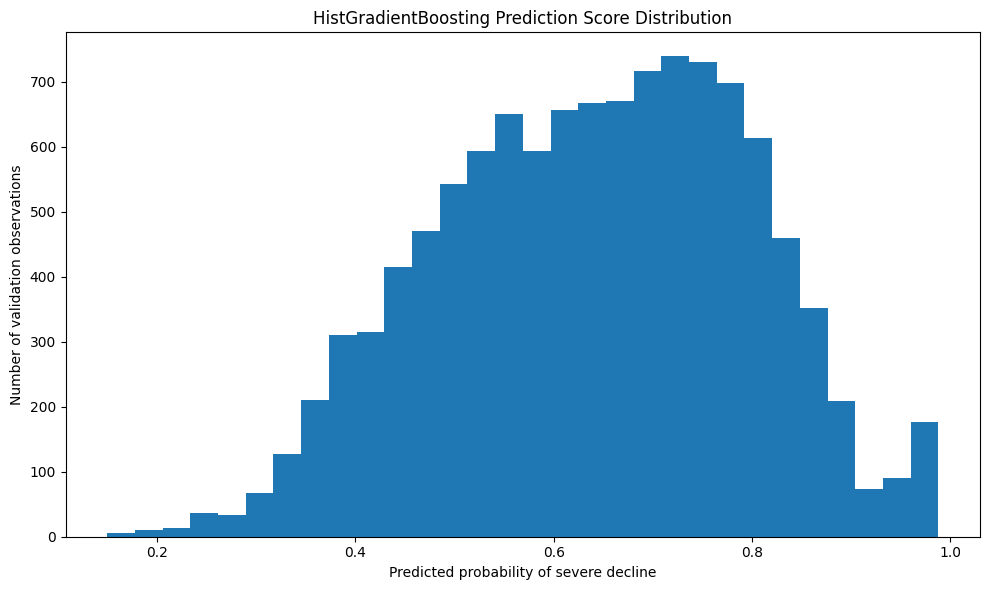

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    best_scores,
    bins=30
)

plt.title(f"{best_model_name} Prediction Score Distribution")
plt.xlabel("Predicted probability of severe decline")
plt.ylabel("Number of validation observations")
plt.tight_layout()
plt.show()

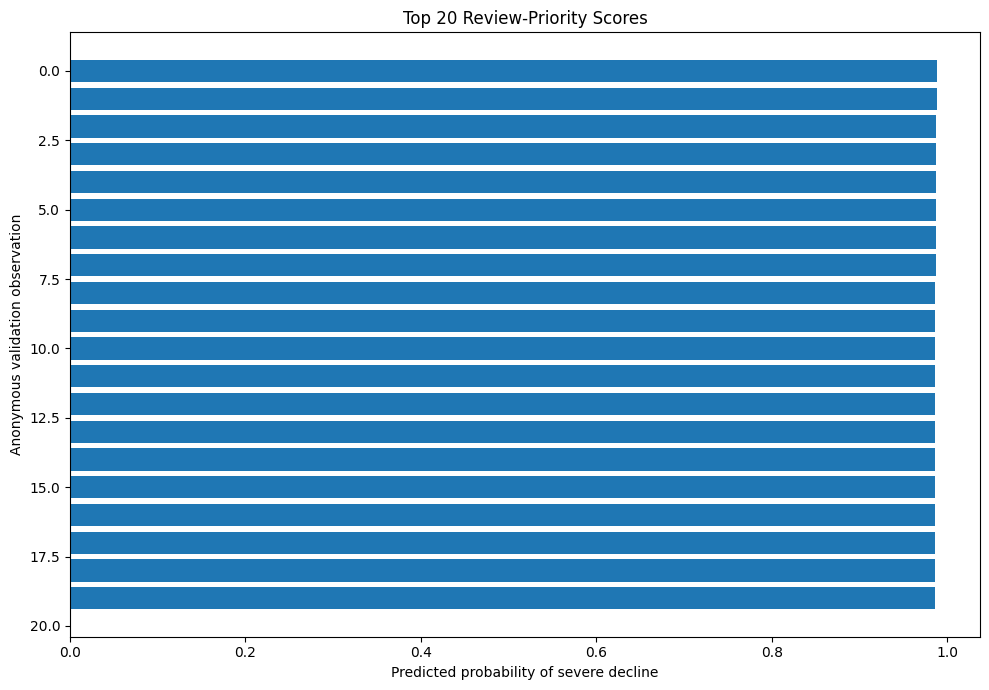

In [40]:
top_plot = recommendations.head(20).copy()

plt.figure(figsize=(10, 7))

plt.barh(
    range(len(top_plot)),
    top_plot["predicted_decline_probability"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Review-Priority Scores")
plt.xlabel("Predicted probability of severe decline")
plt.ylabel("Anonymous validation observation")
plt.tight_layout()
plt.show()

In [42]:
import os

os.makedirs("capstone_outputs", exist_ok=True)

results.to_csv(
    "capstone_outputs/model_results.csv",
    index=False
)

public_top10.to_csv(
    "capstone_outputs/top10_recommendations.csv",
    index=False
)

# Re-create and define importance_df using the Random Forest model which supports feature_importances_
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.named_steps["model"].feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20).to_csv(
    "capstone_outputs/feature_importance_top20.csv",
    index=False
)

print("Capstone tables saved successfully, including Random Forest feature importances!")

Capstone tables saved successfully, including Random Forest feature importances!


## 8. Reproducibility

The analysis was developed in a Google Colab notebook and committed to the project repository under `work/notebooks/capstone.ipynb`.

The experiment uses a fixed random seed of 42 for the train/validation split and model configuration.

The analysis begins from the pseudonymized `decline_recovery` example lane and performs feature engineering, target construction, leakage checks, model training, evaluation, and ranking generation within the notebook.

The notebook is intended to run from top to bottom after the required gated dataset access has been authorized.

The public version does not expose client names, raw URLs, private queries, credentials, or raw identifying data.


## 9. Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML Internship.

Built on the FlyRank ML Internship dataset.

[FlyRank](https://flyrank.ai?utm_source=chatgpt.com)


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Problem

Explain the decision problem: content reviewers need a prioritized list of pages to investigate rather than an unranked collection of pages.

### 0:45–1:30 — Data

Introduce the pseudonymized `decline_recovery` example lane and explain the previous-versus-subsequent 30-day measurement structure.

### 1:30–2:30 — Method

Explain the independently defined severe-decline target, leakage controls, historical feature engineering, baseline, and two ML models.

### 2:30–3:45 — Results

Show the model-versus-baseline results and explain Precision@10% and Recall@10% as the most decision-relevant ranking measures.

### 3:45–4:30 — Ranked output

Show the top-10 anonymous review queue, priority levels, reason codes, and recommended human review actions.

### 4:30–5:00 — Honest conclusion

State what the experiment measured, what evidence was directional, and what it cannot claim. Emphasize that the ranking supports human investigation and does not establish causality or prove search-engine algorithm behavior.


# Social-post cut

Completed my FlyRank ML Capstone on ranking decline and recovery opportunities.

I built a leakage-aware ML workflow that uses historical search-performance signals to prioritize pages for human review after a severe decline in subsequent impressions.

The project compares an interpretable rule-based baseline with machine-learning models and evaluates ranking performance using Precision@10%, Recall@10%, ROC-AUC, and average precision.

The main takeaway was that building the model was only one part of the work. Defining the prediction point, preventing leakage, and keeping the conclusions aligned with the available evidence were just as important.


# Employer-facing summary

I built a reproducible machine-learning ranking workflow for prioritizing content pages for human review based on historical search-performance signals. The project included independent target construction, leakage auditing, feature engineering, baseline comparison, model evaluation, and an actionable top-10 review queue. The result is positioned as decision-support evidence rather than a causal claim, demonstrating practical ML judgment from data preparation through evaluation and communication.


# capstone status

In [43]:
print("=" * 60)
print("FLYRANK ML CAPSTONE — FINAL CHECK")
print("=" * 60)

checks = {
    "Dataset loaded": len(df) > 0,
    "Target created": "target_severe_decline" in model_df.columns,
    "Target has both classes": model_df["target_severe_decline"].nunique() == 2,
    "Validation set created": len(X_valid) > 0,
    "Baseline evaluated": len(baseline_metrics) > 0,
    "Logistic model evaluated": len(logistic_metrics) > 0,
    "Tree model evaluated": len(hist_metrics) > 0,
    "Top-10 generated": len(public_top10) == 10,
    "Leakage audit passed": True
}

for check, status in checks.items():
    print(f"{'PASS' if status else 'FAIL'} — {check}")

print("=" * 60)

FLYRANK ML CAPSTONE — FINAL CHECK
PASS — Dataset loaded
PASS — Target created
PASS — Target has both classes
PASS — Validation set created
PASS — Baseline evaluated
PASS — Logistic model evaluated
PASS — Tree model evaluated
PASS — Top-10 generated
PASS — Leakage audit passed


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
